# 24. Attention Made Visible: Gaussians, KDE, Heatmaps

The text has spent twenty-four chapters making images; this last part turns outward: to the viewer (this chapter), to the ear (chapter 25), to paper (chapter 26), and finally back on itself (chapter 27). We begin with the viewer: the first thing in this text that cannot be generated. Eye trackers record where people look; heatmaps turn such recordings into pictures. Today, for the first time, the data is real: forty-six people each spent a minute with a Kandinsky while an eye tracker wrote down where their gazes landed. We build kernel density estimation with our own hands, render their collective attention, and learn why every attention heatmap is an argument wearing the costume of a measurement.

## Today's destination

Wassily Kandinsky's *Gelb-Rot-Blau* (*Yellow-Red-Blue*, 1925) under the pooled gaze of forty-six real viewers: 7,858 recorded fixations, blurred into a glowing density and composited onto the painting. The recordings come from an eye-tracking study at the instructor's lab <a class="cite" href="#ref-kury2026">(Kury et al. 2026)</a>; the painting is in the public domain, and the chapter's data file ships with the course materials. By the end of today you can turn any list of points into a heatmap, and you will know every dial that quietly shapes what such a picture seems to prove.

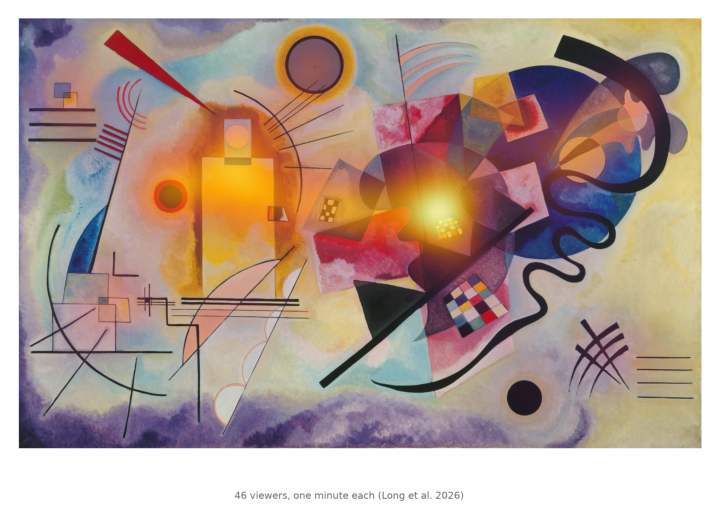

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch24_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(10, 6.5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: the observer observed

First, a confession of scope. Every previous chapter could run without a human in the loop: the machine went alone, because nothing was being measured. Attention is different. It has a ground truth, where people actually look, and that truth lives in viewers' eyes, not in any algorithm. What this chapter builds is therefore not a generator but a **scientific instrument**: the rendering pipeline that turns recorded fixations into a picture.

The desire to measure looking is older than the electronics. In 1879, Louis Émile Javal's laboratory in Paris and Ewald Hering independently reported that a reading eye does not glide along the line but leaps: quick jumps (Javal's **saccades**) separated by still moments, the **fixations** <a class="cite" href="#ref-wade2003">(Wade, Tatler and Heller 2003)</a>. In 1898 Benno Erdmann and Raymond Dodge measured those pauses and argued that only the still moments see anything sharply <a class="cite" href="#ref-erdmann1898">(Erdmann and Dodge 1898)</a>. George Stratton then aimed the young recording technology at an aesthetic question: do our eyes smoothly trace the elegant curves of ornament, as nineteenth-century theories of formal pleasure assumed? They do not; his photographic records showed the same jerky leaps on graceful figures as anywhere else, and a theory of beauty built on the pleasure of smooth eye movement lost its physiological footing <a class="cite" href="#ref-stratton1902">(Stratton 1902)</a>. The first large campaign on pictures came from the educational psychologist Guy Buswell, who photographed the eye movements of some two hundred people looking at artworks and reproductions and found that fixations crowd onto a few dense regions while whole stretches of canvas go unvisited, and that no two viewers distribute their attention quite alike <a class="cite" href="#ref-buswell1935">(Buswell 1935)</a>.

Then, in 1965, the Soviet psychologist **Alfred Yarbus** published a slim book (translated as *Eye Movements and Vision*, 1967) containing one of the most reproduced figures in eye-movement research <a class="cite" href="#ref-tatler2010">(Tatler et al. 2010)</a>. Yarbus attached a tiny mirror to the eye with a suction cap and recorded, with unprecedented precision, the path a viewer's gaze traveled across a picture. His most famous material was a painting: Ilya Repin's *An Unexpected Visitor* (usually catalogued as *They Did Not Expect Him*, 1884–88, Tretyakov Gallery), a returned exile stepping into a family parlor. Yarbus had one viewer examine it seven times, first freely, then with a different errand each time, among them: estimate the family's wealth, estimate their ages, memorize the positions of people and objects, judge how long the visitor had been away. The seven recorded traces look like seven different drawings. Asked about wealth, the gaze combs furniture and clothing; asked about ages, it orbits the faces and barely leaves them. The picture never changed; the question did. **Where we look is a property not of the image alone but of the errand we bring to it** <a class="cite" href="#ref-yarbus1967">(Yarbus 1967)</a>, and that single plate became the emblem of a research tradition.

That tradition has since arrived in art history itself. Raphael Rosenberg, who directs the Vienna lab where this chapter's dataset was recorded <a class="cite" href="#ref-crea">(CReA, history and approach)</a>, proposed treating gaze measurement as a tool of the discipline: art historians have always made claims about how compositions steer the eye, and an eye tracker can check them (<a class="cite" href="#ref-rosenberg2014">Rosenberg 2014</a>; <a class="cite" href="#ref-rosenberg2015">Rosenberg and Klein 2015</a>). The laboratory has also walked into the museum: wearable eye trackers, ordinary-looking glasses with cameras aimed at the eye and at the world, now record visitors moving freely through real galleries. When the Belvedere in Vienna rearranged its permanent collection, a mobile eye-tracking study with 259 visitors could show that the new display lengthened both artwork viewing and label reading <a class="cite" href="#ref-reitstatter2020">(Reitstätter et al. 2020)</a>. This is the instructor's own research field, and this is the point where the notebook opens a real dataset.

The standard summary picture of such recordings is the **attention heatmap**: fixations pooled over viewers, blurred into a smooth density, painted over the artwork in glowing false color. Heatmaps are genuinely useful, and they are also rhetoric. They *look* like objective instrument output, the weather map of a collective gaze, yet nearly everything about their appearance is authored: how much to blur, which colors mean "hot", how transparent the overlay, where the scale is cut off. Two honest heatmaps of the same data can whisper different conclusions, and the eye-tracking literature itself keeps warning how routinely such pictures are over-read (<a class="cite" href="#ref-bojko2009">Bojko 2009</a>; <a class="cite" href="#ref-holmqvist2011">Holmqvist et al. 2011</a>). Today we build the whole pipeline ourselves precisely so that you know which knobs exist and who turned them.

## The bell curve is a brush

Chapter 2 introduced `rng.normal` and the histogram it produces: the bell curve. You have met the bell twice more since: chapter 16 wove it into the Gabor filter, and chapters 17 and 18 blurred images with it. Now we meet the curve itself as a function, the **Gaussian**:

$$g(x) = \frac{1}{\sigma\sqrt{2\pi}}\; e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

Two dials: $\mu$ slides the bump along the axis, $\sigma$ sets its width. Everything else in that formula is bookkeeping that makes the area under the curve exactly 1. (The letter $e$, which chapter 16 glossed, is a fixed number, roughly 2.718; `np.exp` computes its powers. All we ever need from it: $e^0 = 1$, and $e^{-t}$ dives toward 0 as $t$ grows, which is what makes the curve fall away from its peak.) For pictures, the shape is what matters:

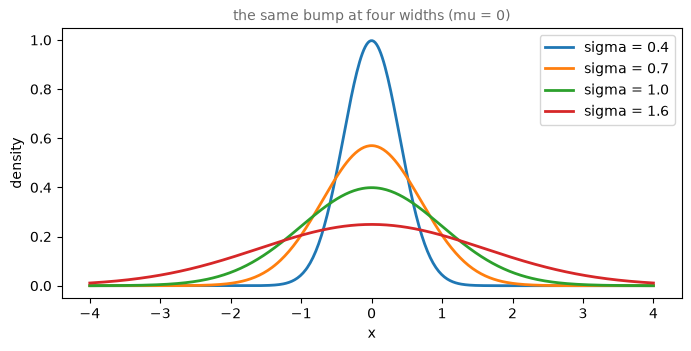

In [2]:
# the Gaussian: one bump, two dials (position mu, width sigma)
import numpy as np

x = np.linspace(-4, 4, 400)
plt.figure(figsize=(8, 3.5))
for sigma in [0.4, 0.7, 1.0, 1.6]:
    curve = np.exp(-x**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    plt.plot(x, curve, linewidth=2, label=f"sigma = {sigma}")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.title("the same bump at four widths (mu = 0)", fontsize=10, color="#6B6B6B")
plt.show()

**Try it.** Edit the previous cell's list of sigmas (add a tiny 0.2 or a huge 3.0) and rerun it; predict the new curve before you look.

A wide $\sigma$ trades height for width: the area stays 1, like the same amount of paint brushed thinner. In two dimensions the bump becomes a hill. We drop the normalizing constant from here on (for pictures only relative height matters):

$$g(x, y) = e^{-\frac{(x-x_0)^2 + (y-y_0)^2}{2\sigma^2}}$$

Remember `np.meshgrid` from chapter 8? It returns the coordinate tables we need to evaluate this on every pixel at once.

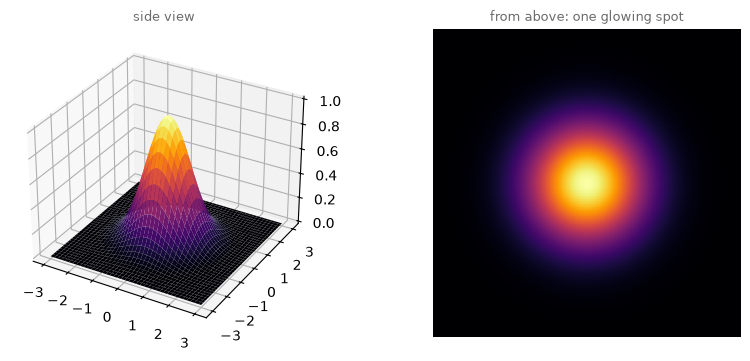

In [3]:
# one fixation becomes a hill: the same 2D Gaussian from the side and from above
grid_x, grid_y = np.meshgrid(np.linspace(-3, 3, 120), np.linspace(-3, 3, 120))
bump = np.exp(-(grid_x**2 + grid_y**2) / (2 * 0.8**2))

fig = plt.figure(figsize=(10, 4))
side = fig.add_subplot(1, 2, 1, projection="3d")   # 3D axes, view only
side.plot_surface(grid_x, grid_y, bump, cmap="inferno")
side.set_title("side view", fontsize=9, color="#6B6B6B")
above = fig.add_subplot(1, 2, 2)
above.imshow(bump, cmap="inferno")
above.set_title("from above: one glowing spot", fontsize=9, color="#6B6B6B")
above.axis("off")
plt.show()

## A sum of bumps: kernel density estimation

Here is the entire idea behind every heatmap you have ever seen. Given $N$ data points, place one Gaussian bump on each and **add them up**:

$$D(x, y) = \sum_{i=1}^{N} e^{-\frac{(x-x_i)^2 + (y-y_i)^2}{2\sigma^2}}$$

Statisticians call this **kernel density estimation** (Kerndichteschätzung), KDE for short: the bump is the *kernel*, and the sum estimates how densely the points cover the plane (the standard reference is <a class="cite" href="#ref-silverman1986">Silverman 1986</a>). The width $\sigma$ is called the **bandwidth**, and it leads a double life. Statistically it is a smoothing parameter: too small and you see individual data points, too large and all structure melts into one blob. Aesthetically it is a brush size. Both lives matter today. First in one dimension, where we can watch the sum happen:

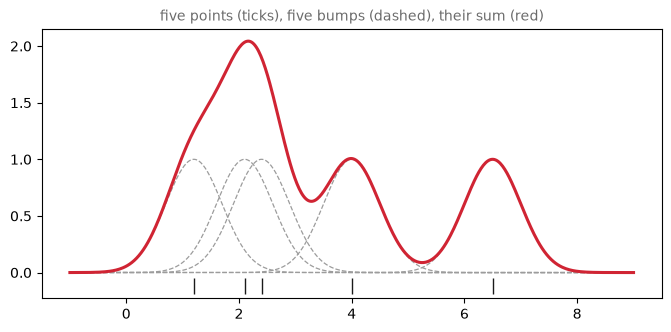

In [4]:
# KDE by hand in 1D: five data points, five bumps, one sum
points = [1.2, 2.1, 2.4, 4.0, 6.5]
sigma = 0.5
x = np.linspace(-1, 9, 500)

density = np.zeros_like(x)
plt.figure(figsize=(8, 3.5))
for p in points:
    bump = np.exp(-(x - p)**2 / (2 * sigma**2))
    plt.plot(x, bump, color="#9C9C9C", linewidth=0.9, linestyle="--")
    density = density + bump
plt.plot(x, density, color="#D02433", linewidth=2.2)
plt.plot(points, np.full(len(points), -0.12), "|", color="#1A1A1A", markersize=12)
plt.title("five points (ticks), five bumps (dashed), their sum (red)",
          fontsize=10, color="#6B6B6B")
plt.show()

The two close points at 2.1 and 2.4 merge into a single hill taller than any lone bump: density rewards *company*. The isolated point at 6.5 keeps its modest solo hill.

**Try it.** Rerun the cell with `sigma = 0.1` and then `sigma = 1.5`. At the small bandwidth the pair separates into two peaks; at the large one all five points fuse into a single dune. The question "at which $\sigma$ do two points become one hill?" is the entire bandwidth debate in miniature.

## A painting and its audience

Our canvas is Wassily Kandinsky's *Gelb-Rot-Blau* (*Yellow-Red-Blue*): oil on canvas, 128 × 201.5 cm, painted in 1925 during his Bauhaus years, the same period as his design treatise *Punkt und Linie zu Fläche* (published 1926 as Bauhausbücher 9; <a class="cite" href="#ref-bauhausbuecher">Bauhaus Kooperation, series page</a>), and today in the Musée national d'art moderne, Centre Pompidou, Paris <a class="cite" href="#ref-pompidou">(Centre Pompidou, collection entry)</a>. A fitting canvas for this text: a pioneer of abstraction, painting with the same vocabulary of circles, grids, arcs and fields you have been generating for twenty-three chapters.

And this time the audience is real. In an eye-tracking study at the instructor's lab in Vienna, forty-six adults each viewed twelve figureless paintings (six abstract works, six still lifes) for one minute per painting while a video-based eye tracker recorded their gaze; *Gelb-Rot-Blau* was one of the twelve. The study is reported in <a class="cite" href="#ref-kury2026">Kury et al. (2026)</a>, its recording setup is further documented in <a class="cite" href="#ref-long2026">Long et al. (2026)</a>, and an anonymized version of the data is publicly archived on Zenodo <a class="cite" href="#ref-kury2026data">(Kury et al. 2026, dataset)</a>. The course materials ship this chapter's slice of it: every fixation the forty-six viewers made on the Kandinsky, as a plain CSV with one row per fixation, holding an anonymous viewer number, when the fixation began, how long it lasted (milliseconds), and where it landed (pixel coordinates in the reproduction below). Of the 7,939 fixations recorded in those trials, 81 landed outside the reproduction (on the screen's margins) and were removed; 7,858 remain. No names, no faces, just landing points: the standard shape of published eye-tracking data.

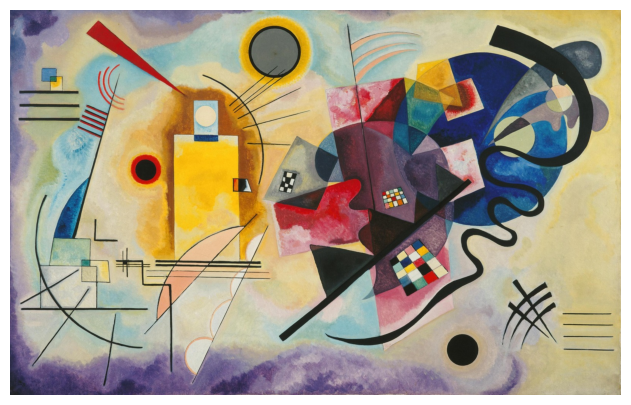

painting array: (1008, 1600, 3)


In [5]:
# load the painting: Kandinsky's Gelb-Rot-Blau (1925), public domain
from PIL import Image

painting = np.asarray(Image.open("../assets/images/kandinsky_yellow_red_blue.jpg")) / 255
height, width = painting.shape[:2]

plt.figure(figsize=(8, 5))
plt.imshow(painting)
plt.axis("off")
plt.show()
print("painting array:", painting.shape)

viewers:    46
fixations:  7858
median duration: 251.0 ms


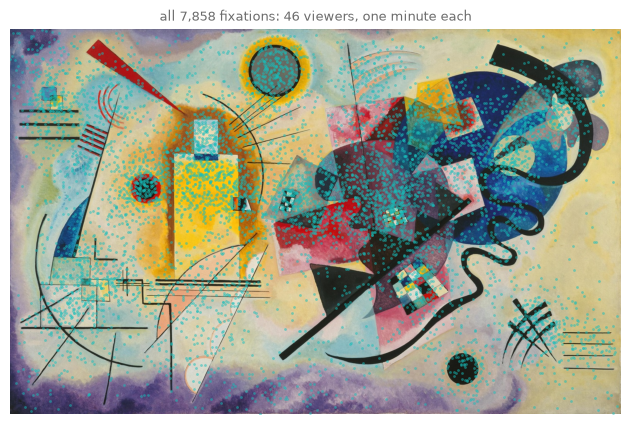

In [6]:
# load the fixations: one CSV row per fixation, 46 real viewers
# np.loadtxt reads a text table into an array, one row per line
fixations = np.loadtxt("../assets/data/kandinsky_fixations.csv",
                       delimiter=",", skiprows=1)     # skiprows: the header line
viewer, start_ms, duration_ms, fix_x, fix_y = fixations.T   # .T: columns out

print("viewers:   ", len(np.unique(viewer)))
print("fixations: ", len(fix_x))
print("median duration:", np.median(duration_ms), "ms")

plt.figure(figsize=(8, 5))
plt.imshow(painting)
plt.scatter(fix_x, fix_y, s=4, color="#17BEBB", alpha=0.5, linewidths=0)
plt.axis("off")
plt.title("all 7,858 fixations: 46 viewers, one minute each",
          fontsize=9, color="#6B6B6B")
plt.show()

Even as a raw scatter the data has opinions. The dots crowd the two small checkered grids right of center, the yellow field, the junction where the red and violet shapes meet; the pale margins go almost unvisited. Two forces produce this pattern. One is the image: small, high-contrast, information-dense details attract fixations, exactly as Buswell measured on his two hundred viewers <a class="cite" href="#ref-buswell1935">(Buswell 1935)</a>. The other is the viewer: people looking at pictures on screens favor the central region regardless of what is painted there <a class="cite" href="#ref-tatler2007">(Tatler 2007)</a>, and each of the forty-six brought whatever errand they brought. The dots do not say which force placed them, and after Yarbus you know better than to assume the image did it alone.

Could an algorithm have predicted this pattern? **Saliency models** attempt exactly that: score every location of an image by how strongly it is expected to draw the eye, an idea proposed by <a class="cite" href="#ref-koch1985">Koch and Ullman (1985)</a>, turned into a working model by <a class="cite" href="#ref-itti1998">Itti, Koch and Niebur (1998)</a> and <a class="cite" href="#ref-itti2000">Itti and Koch (2000)</a>, and today dominated by deep networks whose predictions are judged against recorded fixations of exactly this kind <a class="cite" href="#ref-kummerer2023">(Kümmerer and Bethge 2023)</a>. Art historians have watched parts of that tradition with a raised eyebrow: saliency pictures are computed simulations, yet they circulate as if they showed measured attention, often with little validation against real gazes <a class="cite" href="#ref-rosenbergsaliency">(Rosenberg, *Saliency Maps* project)</a>. Every dot above, for the record, came out of a human eye.

## The heatmap by hand

A heatmap is nothing but our sum of bumps evaluated on a pixel grid. The recipe: build a coordinate grid with `np.meshgrid`, start from zeros, loop over the fixations, add one 2D bump per fixation. A Python loop over all 7,858 fixations would keep us waiting, so the manual version gets a single viewer and a coarse grid; the point of doing it by hand is to *see the sum*, not to win a race. Compiled shortcuts come right after.

viewer 1 made 128 fixations


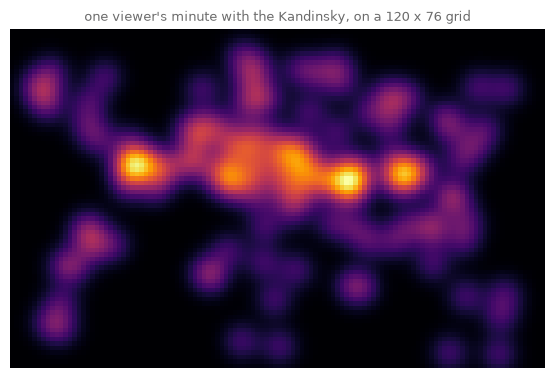

In [7]:
# manual KDE: one viewer's fixations, one bump each, summed on a coarse grid
def kde_manual(xs, ys, bandwidth, grid_w, grid_h):
    # reads the painting's width/height from above; the finished instrument
    # later asks the image itself
    grid_x, grid_y = np.meshgrid(np.linspace(0, width, grid_w),
                                 np.linspace(0, height, grid_h))
    density = np.zeros_like(grid_x)
    for x, y in zip(xs, ys):
        density += np.exp(-((grid_x - x)**2 + (grid_y - y)**2)
                          / (2 * bandwidth**2))
    return density

one = viewer == 1                # a mask: True on viewer 1's rows only
print(f"viewer 1 made {int(one.sum())} fixations")
coarse = kde_manual(fix_x[one], fix_y[one], bandwidth=40, grid_w=120, grid_h=76)

plt.figure(figsize=(7, 4.4))
plt.imshow(coarse, cmap="inferno")
plt.axis("off")
plt.title("one viewer's minute with the Kandinsky, on a 120 x 76 grid",
          fontsize=9, color="#6B6B6B")
plt.show()

One viewer, one minute, one picture of it: the glowing islands sit where this person's gaze pooled, and whole stretches of the canvas never earned a single bump. Density rewards concentration, not coverage (a lesson exercise (c) returns to). To pool all forty-six viewers we want compiled speed, and the library version of the same idea is `scipy.stats.gaussian_kde`. It does two things for us: its inner loop runs in fast compiled code, so all 7,858 fixations on a finer grid become affordable, and it chooses the bandwidth *for* you with a statistical recipe (Scott's rule, derived from the number of points and their spread; <a class="cite" href="#ref-scott1992">Scott 1992</a>). Automatic bandwidth is the right default for statistics; for art we will want our pixel-sized $\sigma$ dial back, which is why the manual version stays in the toolbox.

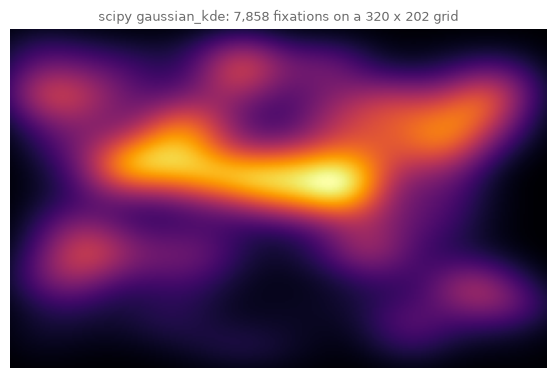

In [8]:
# the library version: scipy's gaussian_kde, all 46 viewers, automatic bandwidth
from scipy.stats import gaussian_kde

kde = gaussian_kde(np.vstack([fix_x, fix_y]))   # vstack: two lists as rows
grid_x, grid_y = np.meshgrid(np.linspace(0, width, 320),
                             np.linspace(0, height, 202))
fine = kde(np.vstack([grid_x.ravel(), grid_y.ravel()])).reshape(grid_x.shape)

plt.figure(figsize=(7, 4.4))
plt.imshow(fine, cmap="inferno")
plt.axis("off")
plt.title("scipy gaussian_kde: 7,858 fixations on a 320 x 202 grid",
          fontsize=9, color="#6B6B6B")
plt.show()

## The overlay, and the honesty of colormaps

A heatmap floating alone says little; it wants to lie on top of the thing that was looked at. Layering is **alpha compositing**: with opacity $\alpha$, each screen pixel shows

$$\text{result} = \alpha \cdot \text{heat} + (1 - \alpha) \cdot \text{painting}$$

In matplotlib we simply call `imshow` twice, the second time with `alpha=`. The remaining choice is the colormap, and it is not innocent. Chapter 5 taught that equal steps in RGB are not equal steps to the eye; colormaps inherit the problem. The classic `jet` rainbow has bright bands in physically arbitrary places, so it *invents* edges and hotspots that do not exist in the data <a class="cite" href="#ref-borland2007">(Borland and Taylor 2007)</a>. `magma` and `inferno` are perceptually uniform: equal data steps look like equal steps, all the way up (which is why this text has reached for them since the fractal chapters). Compare the same density in all three:

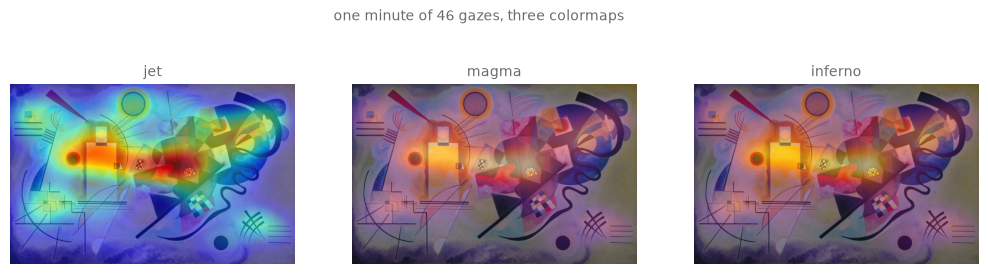

In [9]:
# same data three ways: the colormap is an editorial decision
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
for ax, cmap in zip(axes, ["jet", "magma", "inferno"]):
    ax.imshow(painting)
    # extent= stretches the density grid over the painting's pixel coordinates
    ax.imshow(fine, cmap=cmap, alpha=0.5, extent=[0, width, height, 0])
    ax.set_title(cmap, fontsize=10, color="#6B6B6B")
    ax.axis("off")
fig.suptitle("one minute of 46 gazes, three colormaps",
             fontsize=10, color="#6B6B6B")
plt.show()

**Look and compare.** Under `jet`, the cyan-to-yellow band draws crisp rings around every island, and the mid-density areas pop forward; the map seems to report sharp "zones" of attention. Under `inferno` the same data fades smoothly from nothing to bright. Which rendering would you rather publish if you *wanted* the checkered grids to look dominant? That question has an uncomfortable answer, which is the point: the perceptually uniform maps are not prettier, they are more honest, and the eye-tracking literature is explicit about how easily heatmap readers are misled by such choices <a class="cite" href="#ref-bojko2009">(Bojko 2009)</a>.

**Try it.** In the cell above, change `alpha=0.5` to `0.2` and then `0.8`. At 0.8 the painting nearly disappears under the data; at 0.2 the data becomes a rumor. There is no neutral setting; there are only choices.

## The finished instrument

Two refinements separate our plots so far from a professional overlay. The first is transparency. A flat `alpha=0.5` fogs the *entire* painting, including regions nobody looked at. Better: let the heat layer's transparency follow the density itself, transparent where cold, opaque where hot. A colormap call like `plt.get_cmap("inferno")(density)` returns an RGBA image (chapter 5's RGB plus an **alpha channel**), and we overwrite that fourth channel with the normalized density. One extra dial: raising the density to a small power first (`fade`) pushes the faintest regions to full transparency, so stray glances do not smudge the clean canvas. Cold regions then show the pristine painting, hot regions glow, and yes, `fade` is one more authored choice to disclose.

The second is speed, and you have owned both halves of the trick for chapters: **bin, then blur**. Count the fixations into a 2D histogram with one bin per pixel (`np.histogram2d`, chapter 9's tool), then smooth the counts with a Gaussian blur (chapters 17 and 18 blurred images exactly this way). Blurring a field of point-counts with a Gaussian is the same arithmetic as summing one Gaussian per point: this is binned kernel density estimation, the standard shortcut for large data <a class="cite" href="#ref-silverman1986">(Silverman 1986)</a>, and `scipy.ndimage.gaussian_filter` runs it in compiled code, so 7,858 fixations at full pixel resolution cost next to nothing. As a bonus, the histogram's optional `weights=` lets each fixation count as more or less than one; exercise (b) will feed it the fixation durations.

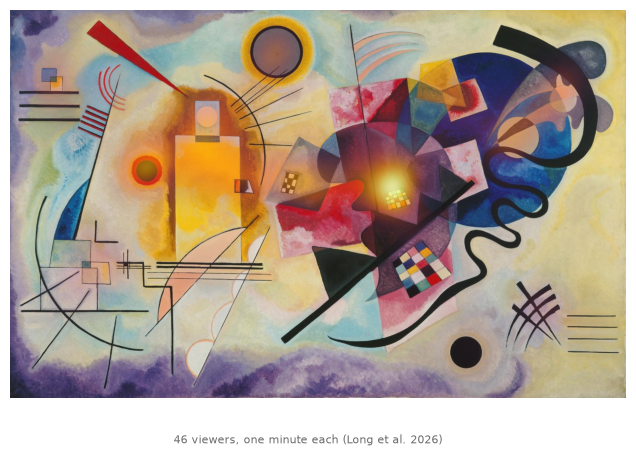

In [10]:
# the finished instrument: fixations in, print-ready attention picture out
import sys
sys.path.append("..")
from scipy.ndimage import gaussian_filter
from agap.helpers import save_artwork

def attention_map(xs, ys, image, bandwidth=40, strength=0.85, fade=1.6,
                  cmap="inferno", weights=None, figsize=8,
                  caption="46 viewers, one minute each (Long et al. 2026)"):
    h, w = image.shape[:2]
    # bin: one cell per pixel, one count (or one weight) per fixation
    counts, _, _ = np.histogram2d(ys, xs, bins=(h, w),
                                  range=[[0, h], [0, w]], weights=weights)
    density = gaussian_filter(counts, sigma=bandwidth, mode="constant")
    density /= density.max()
    heat = plt.get_cmap(cmap)(density)             # RGBA image from the colormap
    # [..., 3] selects channel 3 (alpha) at every pixel
    heat[..., 3] = density**fade * strength        # alpha follows density
    fig = plt.figure(figsize=(figsize, figsize * h / w))
    plt.imshow(image)
    plt.imshow(heat, extent=[0, w, h, 0])
    plt.axis("off")
    fig.text(0.5, 0.02, caption, ha="center", fontsize=8, color="#6B6B6B")
    plt.show()
    return fig

art_1 = attention_map(fix_x, fix_y, painting)

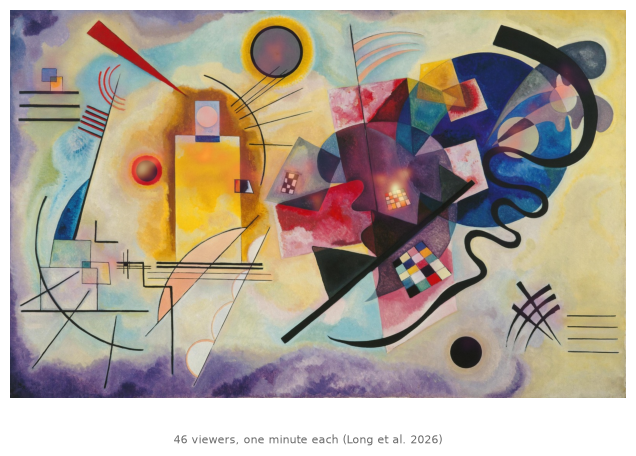

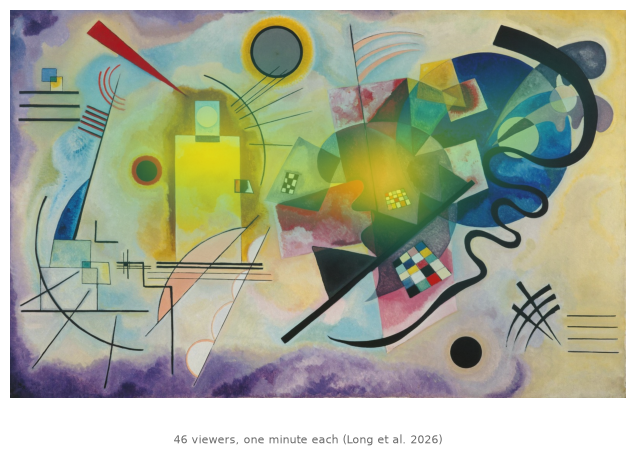

In [11]:
# two more temperaments: the microscope and the weather report
art_2 = attention_map(fix_x, fix_y, painting, bandwidth=12, cmap="magma")
art_3 = attention_map(fix_x, fix_y, painting, bandwidth=110, strength=0.7,
                      cmap="viridis")

**Look and compare.** Three renderings of the identical 7,858 fixations. The microscope (bandwidth 12) nearly resolves the individual landing sites: honest about the data, noisy as a picture. The weather report (bandwidth 110) is seductively smooth and makes the whole canvas look measured, including corners that barely saw a gaze. Which of the three would survive review in a scientific paper, and which would sell a claim about "how people see Kandinsky" to a newspaper? Why are those answers different? There is no escaping the bandwidth dial, only disclosing it.

In [ ]:
# optional sliders -- everything they do, a direct call does too
# (the sliders redraw on every nudge, so they get a quarter-size painting copy
# and quarter-size fixation coordinates to stay snappy)
painting_small = painting[::4, ::4]
def kde_explorer(bandwidth=40, strength=0.85):
    attention_map(fix_x / 4, fix_y / 4, painting_small, bandwidth=bandwidth / 4,
                  strength=strength, figsize=5.5)

try:
    from ipywidgets import interact
    interact(kde_explorer, bandwidth=(8, 160, 4), strength=(0.2, 1.0, 0.05))
except ImportError:
    print("ipywidgets is not installed -- call kde_explorer(40, 0.85) directly")

## Export your artwork

The data is real; the rendering is yours to sign. Choose what your picture argues: the crowd or the individual (filter with the `viewer` column), the first glance or the whole minute (filter with `start_ms`), the quick sweep or the long dwell (pass `duration_ms` as `weights`). Pick a bandwidth and colormap that say what you mean, and set the `caption` to what your filter actually shows: that caption is the scientific conscience of the whole picture. Replace `yourname` and run; the print-quality PNG lands in `assets/outputs/`.

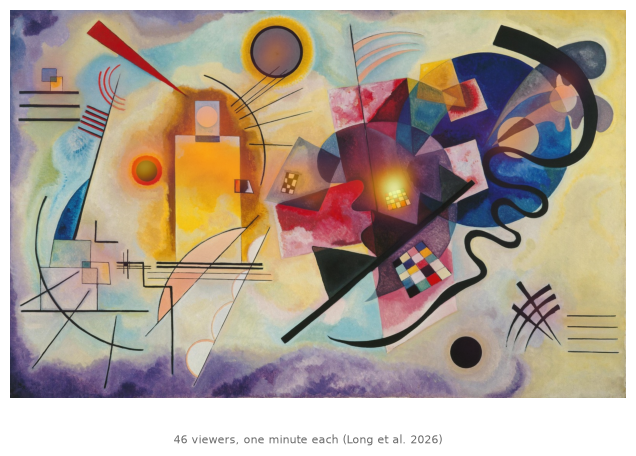

saved: assets/outputs/ch24_yourname.png


In [12]:
# save YOUR artwork: choose viewers, dials, colormap; replace 'yourname'
my_artwork = attention_map(fix_x, fix_y, painting, bandwidth=30, cmap="inferno")
saved_path = save_artwork(my_artwork, "yourname", chapter=24)

## Exercises

**(a) Parameter exploration: where vs that.** Sweep the bandwidth from 8 to 200 in a few steps. Somewhere along the way the map stops showing *where* the fixations fall and starts merely showing *that* they fell. Find the bandwidth where the two checkered grids first fuse into one blob, and the one where the right half's hotspots and the yellow field do. If you had to defend a single "correct" bandwidth for this data, what would your argument even appeal to?

**(b) Code modification: the weight of a glance.** A fixation of 800 ms and a fixation of 80 ms count the same in our density, yet one is ten times the looking. `attention_map` already accepts `weights=`; pass the durations and compare the two maps. Eye-tracking practice treats these as different pictures with different meanings, a fixation-count map versus a dwell-time map <a class="cite" href="#ref-bojko2009">(Bojko 2009)</a>. Where do yours differ, and what does the difference between *landing* somewhere and *staying* there say about those regions?

<details><summary>Solution</summary>

```python
by_count = attention_map(fix_x, fix_y, painting, bandwidth=30)
by_dwell = attention_map(fix_x, fix_y, painting, bandwidth=30,
                         weights=duration_ms,
                         caption="dwell-time weighted; 46 viewers (Long et al. 2026)")
```

The two maps agree broadly: regions that attract many fixations also tend to hold them. Look for the places where they part ways. Wherever the dwell map outshines the count map, glances turned into study; wherever it dims, the eye touched down and immediately moved on.
</details>

**(c) Data exploration: the crowd and the one.** Render `attention_map(fix_x[viewer == v], fix_y[viewer == v], painting, caption=f"viewer {v} only")` for a handful of viewer numbers `v`. How much of the pooled map's structure survives in a single person's single minute? Buswell noticed already in 1935 that no two of his two hundred viewers looked quite alike <a class="cite" href="#ref-buswell1935">(Buswell 1935)</a>; make your own version of that observation, if only by eye.

**(d) Creative challenge: the scanpath.** Heatmaps throw away *time*. The scientific alternative is the scanpath rendering: draw each fixation as a circle (area proportional to its duration), number them in order, and connect consecutive fixations with straight lines (the jumps between fixations are the saccades). Build a `scanpath(xs, ys, durations, image)` function and run it on one viewer (sort that viewer's rows by `start_ms` first). Compare its story to the heatmap's on the same minute: one shows a route, the other a climate. Yarbus's famous plates are scanpaths, not heatmaps <a class="cite" href="#ref-yarbus1967">(Yarbus 1967)</a>; consider what their heatmap versions would have hidden.

## References

**Data and image.** The fixation file `assets/data/kandinsky_fixations.csv` is a de-identified slice of the corpus of <a class="cite" href="#ref-kury2026">Kury et al. (2026)</a>, archived on Zenodo under CC BY 4.0 <a class="cite" href="#ref-kury2026data">(Kury et al. 2026, dataset)</a>: the 7,858 on-painting fixations of all 46 viewers of *Gelb-Rot-Blau*, cropped to the reproduction and rescaled to its shipped 1600 × 1008 pixel size. The reproduction is a public-domain photograph of the painting (Wikimedia Commons), cropped and scaled to the exact pixel frame of the study's stimulus, so the fixation coordinates apply unchanged; the painting itself is in the public domain (Kandinsky died in 1944).

- <span id="ref-bauhausbuecher"></span>Bauhaus Kooperation. *Bauhausbücher*. Knowledge page on the book series, Bauhaus Kooperation Berlin Dessau Weimar. [bauhauskooperation.de](https://bauhauskooperation.de/wissen/publikationen/publikationen-zum-bauhaus/bauhausbuecher). Lists the fourteen volumes, with Kandinsky's *Punkt und Linie zu Fläche* as number 9, 1926.
- <span id="ref-bojko2009"></span>Bojko, A. (2009). Informative or misleading? Heatmaps deconstructed. In J. A. Jacko (ed.), *Human-Computer Interaction: New Trends* (Lecture Notes in Computer Science 5610). Springer. [doi:10.1007/978-3-642-02574-7_4](https://doi.org/10.1007/978-3-642-02574-7_4). The practitioner's catalogue of everything a heatmap reader tends to over-read, including exercise (b)'s count-versus-duration distinction.
- <span id="ref-borland2007"></span>Borland, D., and Taylor, R. M. (2007). Rainbow color map (still) considered harmful. *IEEE Computer Graphics and Applications*, 27(2), 14–17. [doi:10.1109/MCG.2007.323435](https://doi.org/10.1109/MCG.2007.323435). The case against `jet`, made politely and with pictures.
- <span id="ref-buswell1935"></span>Buswell, G. T. (1935). *How People Look at Pictures: A Study of the Psychology of Perception in Art*. University of Chicago Press. The first large-scale eye-tracking study of pictures: some 200 viewers, photographic records, and the discovery that fixations crowd while canvases go unvisited.
- <span id="ref-pompidou"></span>Centre Pompidou. *Gelb-Rot-Blau (Jaune-rouge-bleu), 1925, Vassily Kandinsky*. Collection entry, Musée national d'art moderne, Paris. [centrepompidou.fr/fr/ressources/oeuvre/cEpEKE](https://www.centrepompidou.fr/fr/ressources/oeuvre/cEpEKE). The painting's identification: oil on canvas, 128 × 201.5 cm, gift of Nina Kandinsky, 1976.
- <span id="ref-crea"></span>Cognitive Research in Art History (CReA), University of Vienna. History and approach. [crea.univie.ac.at](https://crea.univie.ac.at/history-approach/). The lab whose corpus this chapter's dataset comes from.
- <span id="ref-erdmann1898"></span>Erdmann, B., and Dodge, R. (1898). *Psychologische Untersuchungen über das Lesen auf experimenteller Grundlage*. Niemeyer. Reading happens in jumps and pauses: the saccade-and-fixation rhythm this chapter's data is made of.
- <span id="ref-holmqvist2011"></span>Holmqvist, K., Nyström, M., Andersson, R., Dewhurst, R., Jarodzka, H., and van de Weijer, J. (2011). *Eye Tracking: A Comprehensive Guide to Methods and Measures*. Oxford University Press. The field's methods handbook; its treatment of attention maps catalogues the choices this chapter turned into dials.
- <span id="ref-itti1998"></span>Itti, L., Koch, C., and Niebur, E. (1998). A model of saliency-based visual attention for rapid scene analysis. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 20(11), 1254–1259. [doi:10.1109/34.730558](https://doi.org/10.1109/34.730558). The first working implementation of the saliency-map idea.
- <span id="ref-itti2000"></span>Itti, L., and Koch, C. (2000). A saliency-based search mechanism for overt and covert shifts of visual attention. *Vision Research*, 40(10–12), 1489–1506. [doi:10.1016/S0042-6989(99)00163-7](https://doi.org/10.1016/S0042-6989(99)00163-7). The classic working saliency model.
- <span id="ref-koch1985"></span>Koch, C., and Ullman, S. (1985). Shifts in selective visual attention: towards the underlying neural circuitry. *Human Neurobiology*, 4, 219–227. The saliency-map idea itself.
- <span id="ref-kummerer2023"></span>Kümmerer, M., and Bethge, M. (2023). Predicting visual fixations. *Annual Review of Vision Science*, 9, 269–291. [doi:10.1146/annurev-vision-120822-072528](https://doi.org/10.1146/annurev-vision-120822-072528). A thorough recent review of fixation-prediction models and of how such predictions are tested against real eye-tracking data.
- <span id="ref-kury2026"></span>Kury, S., Long, X., Arato, J., Kamencek, T., Miscenà, A., and Rosenberg, R. (2026). Visual guidance of pictorial composition in the absence of figures: An eye-tracking study. Preprint, PsyArXiv. [doi:10.31234/osf.io/v6ruk](https://doi.org/10.31234/osf.io/v6ruk). The study whose corpus this chapter's data comes from: 46 observers, 12 figureless paintings, one minute each, eye tracking plus compositional drawing.
- <span id="ref-kury2026data"></span>Kury, S., Long, X., Arato, J., Kamencek, T., Miscenà, A., and Rosenberg, R. (2026). Data for: Visual guidance of pictorial composition in the absence of figures (v1) [dataset]. Zenodo. [doi:10.5281/zenodo.21983283](https://doi.org/10.5281/zenodo.21983283). The archived per-saccade records and compositional-line drawings, CC BY 4.0.
- <span id="ref-long2026"></span>Long, X., Arato, J., Kury, S., Miscena, A., and Rosenberg, R. (2026). HeatMatch: orientation-aware visualization and comparison of very dense saccade patterns. *Proceedings of the ACM on Computer Graphics and Interactive Techniques*, 9(2), Article 18. [doi:10.1145/3803539](https://doi.org/10.1145/3803539). The methods paper built on the same corpus; its saccade-level deposit is archived at [osf.io/f2xhj](https://osf.io/f2xhj/).
- <span id="ref-reitstatter2020"></span>Reitstätter, L., Brinkmann, H., Santini, T., Specker, E., Dare, Z., Bakondi, F., Miscena, A., Kasneci, E., Leder, H., and Rosenberg, R. (2020). The display makes a difference: a mobile eye tracking study on the perception of art before and after a museum's rearrangement. *Journal of Eye Movement Research*, 13(2), 6. [doi:10.16910/jemr.13.2.6](https://doi.org/10.16910/jemr.13.2.6). Eye tracking walking out of the lab: 259 museum visitors, before and after the Belvedere's rehang.
- <span id="ref-rosenberg2014"></span>Rosenberg, R. (2014). Blicke messen: Vorschläge für eine empirische Bildwissenschaft. *Jahrbuch der Bayerischen Akademie der Schönen Künste*, 27 (2013, publ. 2014), 71–86. [Open access via Heidelberg](http://archiv.ub.uni-heidelberg.de/artdok/3028/). The programme of measuring gazes to test art history's claims about how images steer the eye.
- <span id="ref-rosenbergsaliency"></span>Rosenberg, R. (n.d.). *Saliency Maps: Die Verselbstständigung visualisierter Computersimulationen*. Project description, DFG media cultures programme (MECS), Leuphana Universität Lüneburg. [leuphana.de](https://www.leuphana.de/dfg-programme/mecs/personen/alumni/prof-dr-raphael-rosenberg-1.html). The art historian's critique of saliency simulations circulating as if they were measurements.
- <span id="ref-rosenberg2015"></span>Rosenberg, R., and Klein, C. (2015). The moving eye of the beholder: eye tracking and the perception of paintings. In J. P. Huston, M. Nadal, F. Mora, L. F. Agnati, and C. J. Cela-Conde (eds.), *Art, Aesthetics, and the Brain* (pp. 79–108). Oxford University Press. The bridge between eye-movement research and art history, from the historical sources above to modern painting studies.
- <span id="ref-scott1992"></span>Scott, D. W. (1992). *Multivariate Density Estimation: Theory, Practice, and Visualization*. Wiley. Scott's rule, the automatic bandwidth scipy chooses for you.
- <span id="ref-silverman1986"></span>Silverman, B. W. (1986). *Density Estimation for Statistics and Data Analysis*. Chapman and Hall. The standard KDE reference, including the binned computation behind our bin-then-blur shortcut.
- <span id="ref-solso1994"></span>Solso, R. L. (1994). *Cognition and the Visual Arts*. MIT Press. A classic bridge between vision science and art, eye movements included.
- <span id="ref-stratton1902"></span>Stratton, G. M. (1902). Eye-movements and the aesthetics of visual form. *Philosophische Studien*, 20, 336–359. Among the first eye-movement studies to ask an aesthetic question; the eyes refused to trace the ornament smoothly.
- <span id="ref-tatler2007"></span>Tatler, B. W. (2007). The central fixation bias in scene viewing: selecting an optimal viewing position independently of motor biases and image feature distributions. *Journal of Vision*, 7(14), 4. [doi:10.1167/7.14.4](https://doi.org/10.1167/7.14.4). Why screen viewers favor the center regardless of what is shown.
- <span id="ref-tatler2010"></span>Tatler, B. W., Wade, N. J., Kwan, H., Findlay, J. M., and Velichkovsky, B. M. (2010). Yarbus, eye movements, and vision. *i-Perception*, 1(1), 7–27. [doi:10.1068/i0382](https://doi.org/10.1068/i0382). Yarbus's biography and methods, and a sober assessment of what his famous task experiment did and did not show.
- <span id="ref-wade2003"></span>Wade, N. J., Tatler, B. W., and Heller, D. (2003). Dodge-ing the issue: Dodge, Javal, Hering, and the measurement of saccades in eye-movement research. *Perception*, 32(7), 793–804. [doi:10.1068/p3470](https://doi.org/10.1068/p3470). Who saw the jumps first: the 1879 priority of Javal's laboratory and Hering over Erdmann and Dodge.
- <span id="ref-yarbus1967"></span>Yarbus, A. L. (1967). *Eye Movements and Vision* (B. Haigh, trans.). Plenum Press. The original plates, including the seven Repin records; still astonishing.
- The [matplotlib colormap guide](https://matplotlib.org/stable/users/explain/colors/colormaps.html): every built-in map plotted with its lightness profile, so you can see honesty directly.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook: the full 46-viewer attention overlay at pixel resolution. It runs automatically with *Restart & Run All*.

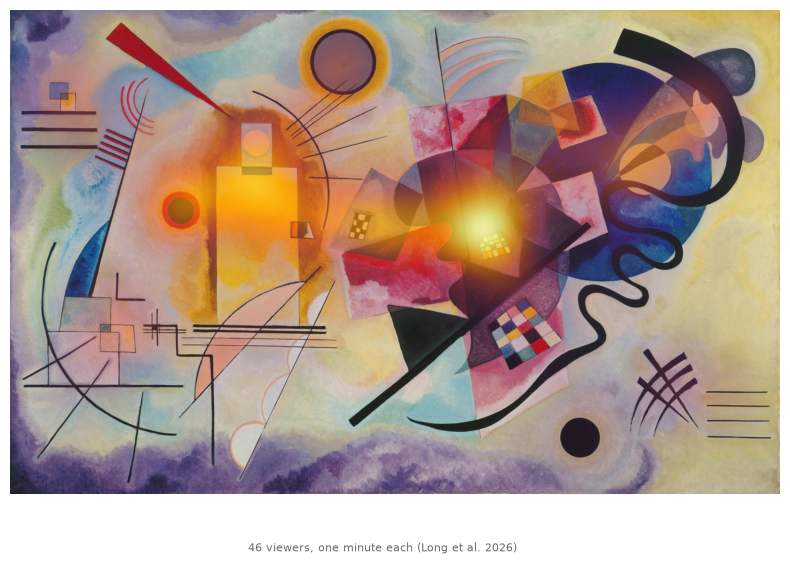

saved: assets/outputs/ch24_showpiece.png


In [13]:
# regenerate this chapter's showpiece: the Kandinsky and its real audience
showpiece = attention_map(fix_x, fix_y, painting, bandwidth=60, strength=0.9,
                          fade=1.2, cmap="inferno", figsize=10)
saved_path = save_artwork(showpiece, "showpiece", chapter=24)